# Training a graph neural network potential for TiZrNb, end to end

This notebook walks the full pipeline of this repository in miniature: generate
a small teacher-labeled dataset, build periodic graphs, train the from-scratch
message-passing potential, evaluate it honestly, and check the physics. Every
step shows a picture. The committed benchmark numbers in the README come from
the full configs in `configs/`, not from this miniature run.

**Label integrity, stated up front:** every energy and force label below is a
surrogate model label from a pretrained universal potential (CHGNet), which was
itself trained on DFT. Nothing in this notebook is DFT data; the only real DFT
in the repository is the Materials Project anchor set used by the EOS benchmark.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from gnff import (
    MpnnConfig,
    MpnnPotential,
    RidgePotential,
    TrainSettings,
    build_batch,
    evaluate_potential,
    group_split,
    train_potential,
)
from gnff.dataset import build_dataset
from gnff.evaluate import predict

torch.manual_seed(0)
COLORS = {"mpnn": "#2a78d6", "ridge": "#1baf7a"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.color": "#e1e0d9",
                     "grid.linewidth": 0.6, "font.size": 10})

## 1. Generate a miniature teacher-labeled dataset

The full recipe (`configs/dataset.yaml`) covers nine compositions with rattle,
strain, and teacher-MD batches, about 1,500 frames. Here we use three
compositions and two batch kinds, enough to train a small model in minutes.
Each batch is one generation group; the split later moves whole groups only.

In [2]:
mini_cfg = {
    "teacher": "chgnet",
    "seed": 20260807,
    "compositions": ["Ti", "Nb", "TiZrNb"],
    "holdout_compositions": [],
    "reps_small": 2,
    "reps_large": 2,
    "rattle_amplitudes": [0.06, 0.14],
    "rattle_frames_per_batch": 16,
    "rattle_frames_large": 4,
    "strain_frames_per_batch": 12,
    "md_temperatures_k": [],
    "md_steps": 0,
    "md_sample_every": 1,
}
frames, provenance = build_dataset(mini_cfg)
print(f"{provenance['n_frames']} frames in {provenance['n_groups']} groups, "
      f"{provenance['labeling_seconds_per_frame']*1000:.0f} ms per teacher call")
print("labels are:", provenance["label_source"])

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet will run on cpu
generated Ti: 48 frames so far


generated Nb: 96 frames so far


generated TiZrNb: 144 frames so far


H:\Projects_for_Github\_workspace\scratch\gnff_repro\venv\Lib\site-packages\chgnet\model\model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)


144 frames in 15 groups, 99 ms per teacher call
labels are: surrogate model labels from a pretrained universal potential, NOT DFT


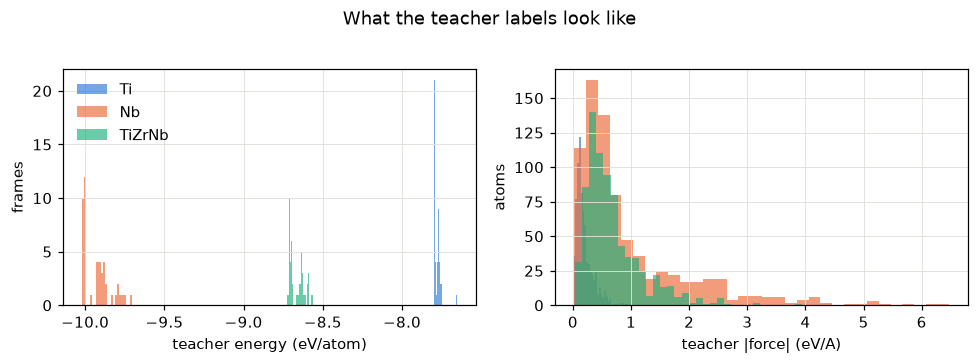

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for comp, color in zip(("Ti", "Nb", "TiZrNb"), ("#2a78d6", "#eb6834", "#1baf7a")):
    sel = [fr for fr in frames if fr.composition == comp]
    e = [fr.energy / fr.n_atoms for fr in sel]
    f = np.concatenate([np.linalg.norm(fr.forces, axis=1) for fr in sel])
    axes[0].hist(e, bins=24, alpha=0.65, label=comp, color=color)
    axes[1].hist(f, bins=32, alpha=0.65, label=comp, color=color)
axes[0].set_xlabel("teacher energy (eV/atom)"); axes[0].set_ylabel("frames"); axes[0].legend(frameon=False)
axes[1].set_xlabel("teacher |force| (eV/A)"); axes[1].set_ylabel("atoms")
fig.suptitle("What the teacher labels look like", y=1.02)
fig.tight_layout(); plt.show()

Distinct chemistry, visible immediately: Nb sits deeper in energy and
stiffer in forces than Ti, and the alloy interpolates with extra disorder
broadening. The model has to learn all of it from local environments.

## 2. From structures to periodic graphs

The message-passing model consumes a directed edge list with periodic shift
vectors. The neighbor list handles general triclinic (strained) cells and
atoms outside the box, and is unit-tested against `ase.neighborlist`.

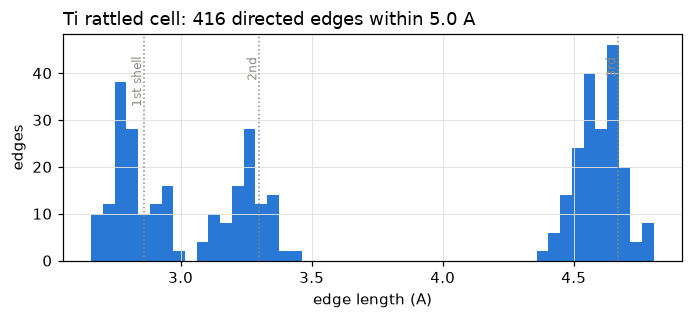

In [4]:
fr = frames[0]
batch = build_batch([fr], cutoff=5.0)
r = np.linalg.norm(
    (batch.positions[batch.edge_j] + batch.shift_vec - batch.positions[batch.edge_i]).numpy(),
    axis=1,
)
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.hist(r, bins=48, color="#2a78d6")
for shell, x in (("1st shell", 2.86), ("2nd", 3.30), ("3rd", 4.67)):
    ax.axvline(x, color="#898781", lw=1, ls=":")
    ax.annotate(shell, (x, ax.get_ylim()[1] * 0.9), rotation=90, fontsize=8,
                color="#898781", ha="right", va="top")
ax.set_xlabel("edge length (A)"); ax.set_ylabel("edges")
ax.set_title(f"{fr.composition} rattled cell: {len(r)} directed edges within 5.0 A", loc="left")
fig.tight_layout(); plt.show()

The BCC shell structure survives the rattle: first and second neighbor
shells blur together (8 + 6 neighbors), the third sits near the cutoff. Message
passing sees three shells directly and further shells indirectly, one extra
hop per interaction block.

## 3. Leakage-safe split, then train

Sibling frames from one rattle batch are near-duplicates. The split therefore
moves whole generation groups; a random-frame split would leak siblings across
the boundary. How much that flatters a model depends on the model: the
`split_gap` benchmark on the full dataset measures about 15 percent energy
flattery (and a 5x collapse of the seed spread) for the descriptor network,
and none at all for the GNN at this capacity and budget. Details in
RESULTS.md.

In [5]:
split = group_split(frames, holdout_compositions=(), seed=0)
train = [frames[k] for k in split.train]; val = [frames[k] for k in split.val]
test = [frames[k] for k in split.test]
print(f"train {len(train)} / val {len(val)} / test {len(test)} frames "
      f"({len({fr.group for fr in train})} / {len({fr.group for fr in val})} / "
      f"{len({fr.group for fr in test})} groups)")

model = MpnnPotential(MpnnConfig(hidden=32, n_blocks=3, n_rbf=16, cutoff=5.0))
print(f"{model.n_parameters():,} parameters")
report = train_potential(model, train, val,
                         TrainSettings(epochs=30, batch_size=16, lr=1e-3,
                                       force_weight=0.1, val_every=3, seed=0),
                         log_every=10)

train 80 / val 32 / test 32 frames (7 / 4 / 4 groups)
18,018 parameters


epoch 10/30 loss 0.01673


epoch 20/30 loss 0.00420


epoch 30/30 loss 0.00269 val E 13.66 meV/atom F 55.8 meV/A


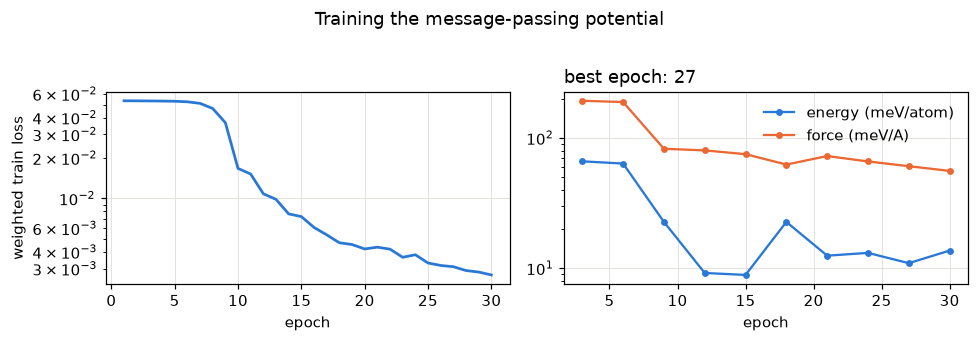

In [6]:
hist = report["history"]
val_pts = [h for h in hist if "val_e_mae" in h]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
axes[0].plot([h["epoch"] for h in hist], [h["train_loss"] for h in hist], color="#2a78d6", lw=1.8)
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("weighted train loss")
axes[1].plot([h["epoch"] for h in val_pts], [h["val_e_mae"] for h in val_pts], "-o",
             color="#2a78d6", ms=3.5, label="energy (meV/atom)")
axes[1].plot([h["epoch"] for h in val_pts], [h["val_f_mae"] for h in val_pts], "-o",
             color="#eb6834", ms=3.5, label="force (meV/A)")
axes[1].set_yscale("log"); axes[1].set_xlabel("epoch"); axes[1].legend(frameon=False)
axes[1].set_title(f"best epoch: {report['best_epoch']}", loc="left")
fig.suptitle("Training the message-passing potential", y=1.02)
fig.tight_layout(); plt.show()

## 4. Evaluate honestly: parity on held-out groups

Test frames come from generation groups the model never saw. We also fit the
ridge baseline on the hand-built ACSF descriptors to see what the extra
machinery buys at this (small) data size. Keep in mind what this miniature
dataset is: gentle rattles and strains only, no high-temperature MD and no
0.18 A rattles. On such near-harmonic data a linear model is a strong force
predictor, so do not expect the full benchmark's gaps here.

In [7]:
ridge = RidgePotential()
ridge.fit(train, val, force_weight=0.1)
results = {}
for name, m in (("mpnn", model), ("ridge", ridge)):
    e_mae, f_mae = evaluate_potential(m, test)
    results[name] = (e_mae, f_mae)
    print(f"{name:6s}  test energy MAE {e_mae:6.2f} meV/atom   force MAE {f_mae:6.1f} meV/A")

mpnn    test energy MAE  18.21 meV/atom   force MAE   46.2 meV/A
ridge   test energy MAE  27.78 meV/atom   force MAE   37.0 meV/A


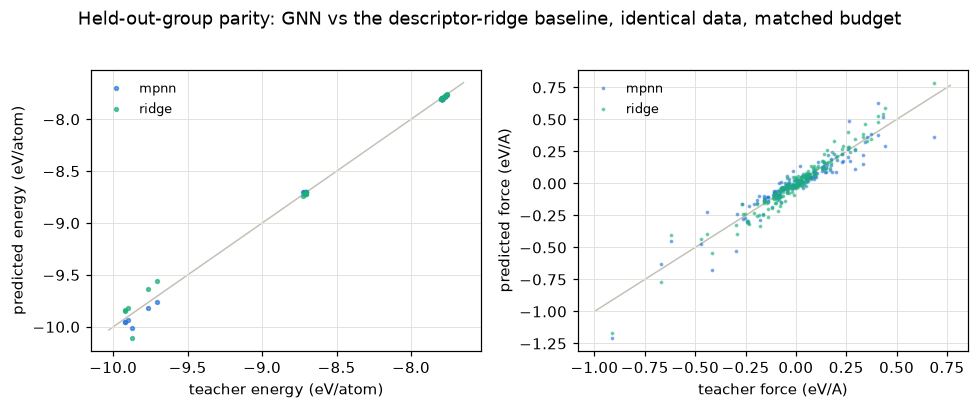

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for name, m in (("mpnn", model), ("ridge", ridge)):
    e_pred, f_pred = predict(m, test)
    e_true = np.array([fr.energy / fr.n_atoms for fr in test])
    axes[0].plot(e_true, e_pred / np.array([fr.n_atoms for fr in test]), ".",
                 ms=5, alpha=0.7, color=COLORS[name], label=name)
    f_true = np.concatenate([fr.forces for fr in test]).ravel()
    axes[1].plot(f_true[::9], f_pred.ravel()[::9], ".", ms=3, alpha=0.5,
                 color=COLORS[name], label=name)
for ax, lab in zip(axes, ("energy (eV/atom)", "force (eV/A)")):
    lo, hi = ax.get_xlim()
    ax.plot([lo, hi], [lo, hi], color="#c3c2b7", lw=1, zorder=0)
    ax.set_xlabel(f"teacher {lab}"); ax.set_ylabel(f"predicted {lab}")
    ax.legend(frameon=False, fontsize=8.5)
fig.suptitle("Held-out-group parity: GNN vs the descriptor-ridge baseline, "
             "identical data, matched budget", y=1.02)
fig.tight_layout(); plt.show()

## 5. Physics check: continuity, invariance, conservation

A potential is only usable for simulation if its energy surface is smooth at
the cutoff, invariant under symmetries, and force-consistent. These are also
unit tests; here we look at the trained miniature model.

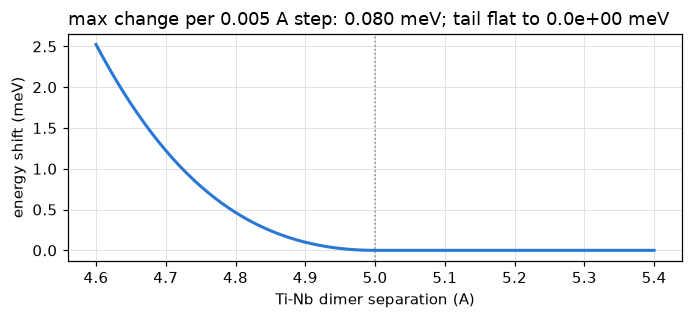

rotation invariance     : 0.00e+00 meV
translation invariance  : 0.00e+00 meV
permutation invariance  : 2.84e-11 meV
autograd vs finite diff : 1.12e-08 eV/A


In [9]:
from gnff.physics import dimer_scan, force_consistency, invariance_report

scan = dimer_scan(model, span=0.4, step=0.005)
inv = invariance_report(model)
fc = force_consistency(model)
fig, ax = plt.subplots(figsize=(6.4, 3.0))
d = np.array(scan["distances"]); e = 1000 * (np.array(scan["energies_ev"]) - scan["energies_ev"][-1])
ax.plot(d, e, color="#2a78d6", lw=2)
ax.axvline(scan["cutoff"], color="#898781", lw=1, ls=":")
ax.set_xlabel("Ti-Nb dimer separation (A)"); ax.set_ylabel("energy shift (meV)")
ax.set_title(f"max change per 0.005 A step: {scan['max_step_change_mev']:.3f} meV; "
             f"tail flat to {scan['tail_flatness_mev']:.1e} meV", loc="left")
fig.tight_layout(); plt.show()
print(f"rotation invariance     : {inv['rotation_delta_mev']:.2e} meV")
print(f"translation invariance  : {inv['translation_delta_mev']:.2e} meV")
print(f"permutation invariance  : {inv['permutation_delta_mev']:.2e} meV")
print(f"autograd vs finite diff : {fc['max_abs_error_ev_per_a']:.2e} eV/A")

## 6. Equation of state against the teacher

Final check: scan the lattice constant of BCC Nb and compare the trained
miniature model's E-V curve with the teacher it was distilled from. The full
benchmark also compares against real-DFT Materials Project anchors; the
miniature model has seen far less data, so expect a rougher curve than the
committed `results/eos.json`.

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet will run on cpu


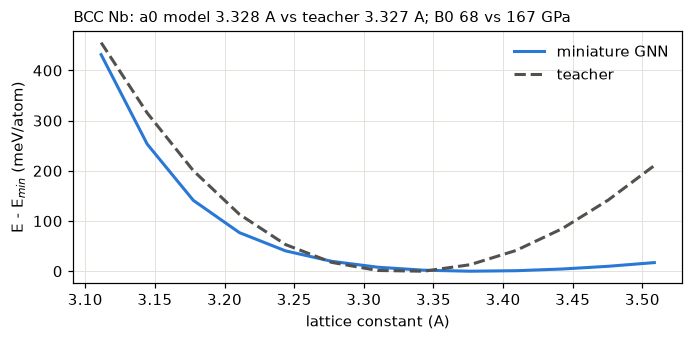

In [10]:
from gnff.eos import model_eos, teacher_eos
from gnff.labeling import get_teacher

calc, _ = get_teacher("chgnet")
m_fit = model_eos(model, "Nb"); t_fit = teacher_eos(calc, "Nb")
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for fit, color, ls, label in ((m_fit, "#2a78d6", "-", "miniature GNN"),
                              (t_fit, "#52514e", "--", "teacher")):
    v = np.array(fit["volumes"]); e = np.array(fit["energies_per_atom"])
    a = (2 * v) ** (1 / 3)
    ax.plot(a, 1000 * (e - e.min()), ls, color=color, lw=2, label=label)
ax.set_xlabel("lattice constant (A)"); ax.set_ylabel("E - E$_{min}$ (meV/atom)")
ax.set_title(f"BCC Nb: a0 model {m_fit['a0_angstrom']:.3f} A vs teacher "
             f"{t_fit['a0_angstrom']:.3f} A; B0 {m_fit['b0_gpa']:.0f} vs "
             f"{t_fit['b0_gpa']:.0f} GPa", loc="left", fontsize=9.5)
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## Where to go next

- `python scripts/run_all.py` reproduces every committed number (full dataset,
  all six benchmarks, figures) in a few hours on CPU.
- The README carries the real headline results: the data-efficiency curves
  (the hero figure), the matched-budget comparison, the split-protocol gap,
  EOS against teacher and DFT anchors, and NVE drift.
- `docs/model_card.md` documents the committed checkpoints, their data, and
  their limits; `docs/api.md` documents the library API.

Two honest observations to carry away. In THIS miniature, near-harmonic
regime the 147-parameter ridge model is genuinely competitive (it can even
beat the small GNN on forces), which is exactly why fair baselines matter.
On the full dataset, with high-temperature MD batches and larger rattles,
the picture changes: message passing buys the most on forces and at
small-to-medium training sizes, while the descriptor baselines remain
respectable on full-data energies for this narrow BCC chemistry. Details
and numbers in RESULTS.md.